save .nc from flux and flux-x's first year_month to tiff, to compare difference

In [ ]:
year_month = '2001-01'
nee_file_path = f'../gis/NEE/NEE.RS.FP-NONE.MLM-ALL.METEO-NONE.4320_2160.monthly.{year_month[:4]}.nc'
xbase_nee_file_path = f'../gis/NEE_FLUX-X/NEE_{year_month[:4]}_005_monthly.nc'


from rasterio.transform import Affine
import rasterio
import numpy as np
import xarray as xr
NEE_CRS = "EPSG:4326"

nee_transform = Affine(*(0.08333333333333333, 0.0, -180.0,
       0.0, -0.08333333333333333, 90.0))
xbase_nee_transform = Affine(*(0.05, 0.0, -179.975,
       0.0, -0.05, 89.975))

# Open the NEE file using xarray
nee_ds = xr.open_dataset(nee_file_path)
nee_data = nee_ds['NEE'].isel(time=0).values  # Extract the first month's data

# Open the XBASE NEE file using xarray
xbase_nee_ds = xr.open_dataset(xbase_nee_file_path)
xbase_nee_data = xbase_nee_ds['NEE'].isel(time=0).values  # Extract the first month's data

# Save NEE data to a .tif file
nee_tif_path = f'../gis/test/NEE_FLUX_{year_month}.tif'
with rasterio.open(
    nee_tif_path,
    'w',
    driver='GTiff',
    height=nee_data.shape[0],
    width=nee_data.shape[1],
    count=1,
    dtype=nee_data.dtype,
    crs=NEE_CRS,
    transform=nee_transform,
) as dst:
    dst.write(nee_data, 1)

# Save XBASE NEE data to a .tif file
xbase_nee_tif_path = f'../gis/test/NEE_XBASE_{year_month}.tif'
with rasterio.open(
    xbase_nee_tif_path,
    'w',
    driver='GTiff',
    height=xbase_nee_data.shape[0],
    width=xbase_nee_data.shape[1],
    count=1,
    dtype=xbase_nee_data.dtype,
    crs=NEE_CRS,
    transform=xbase_nee_transform,
) as dst:
    dst.write(xbase_nee_data, 1)

compare msa mean trend

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from constants import NEE_MSA_MONTHLY_MEAN, NEE_MSA_MONTHLY_MEAN_XBASE

In [3]:
nee = pd.read_csv(NEE_MSA_MONTHLY_MEAN)
nee_xbase = pd.read_csv(NEE_MSA_MONTHLY_MEAN_XBASE)

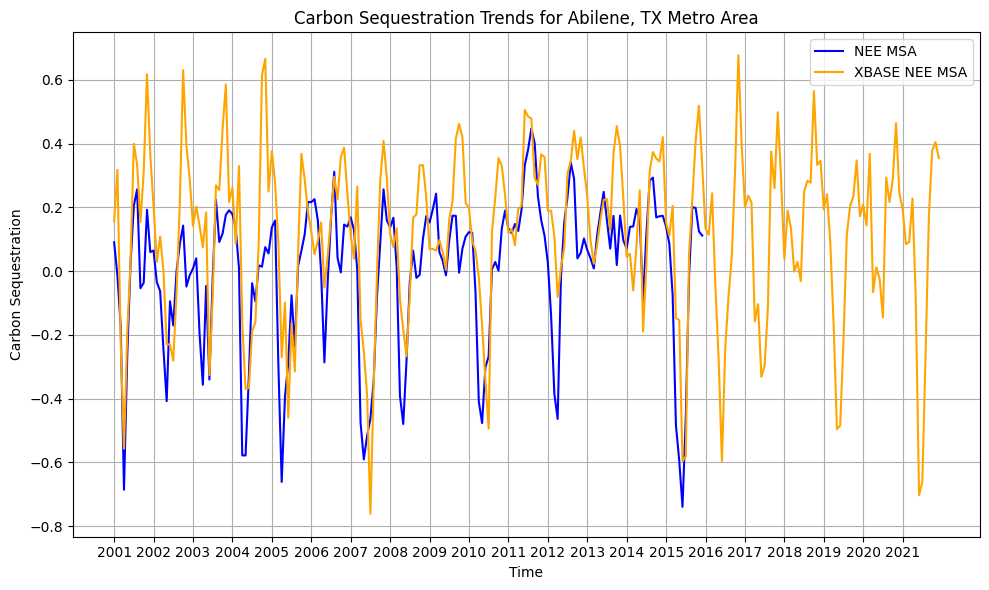

In [7]:
msa_name = 'Abilene, TX Metro Area'
nee_msa = nee[nee['NAMELSAD'] == msa_name]
xbase_msa = nee_xbase[nee_xbase['NAMELSAD'] == msa_name]
save_path = f'../test/NEE_trend_compare_flux-xbase_{msa_name}.png'

plt.figure(figsize=(10, 6))
plt.plot(nee_msa.columns[1:], nee_msa.iloc[0, 1:], label='NEE MSA', color='blue')
plt.plot(xbase_msa.columns[1:], xbase_msa.iloc[0, 1:], label='XBASE NEE MSA', color='orange')
plt.title(f'Carbon Sequestration Trends for {msa_name}')
plt.xlabel('Time')
plt.ylabel('Carbon Sequestration')
plt.xticks(ticks=np.arange(0, len(xbase_msa.columns[1:]), 12), labels=[year[9:13] for year in xbase_msa.columns[1:][::12]])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
def plot_seasonal_change(df, info, show_mean=False):
    '''
    df (pd.DataFrame): DataFrame with time series data. and a single column of 'NAMELSAD'
    info (dict) {'title': (str), 'xlabel': (str), 'ylabel': (str)}
    '''
    
    title, xlabel, ylable = info['title'], info['xlabel'], info['ylabel']
    plt.figure(figsize=(12, 6))
    

    if show_mean:
        mean_values = df.iloc[:, 1:].mean(axis=0)
        plt.plot(df.columns[1:], mean_values, color='red', label='Mean of Carbon Sequestration', linewidth=2, zorder=3)
        for index, row in df.iterrows():
            plt.plot(row.index[1:], row.values[1:], color='grey', alpha=0.5)
    else:
        for index, row in df.iterrows():
            plt.plot(row.index[1:], row.values[1:], label=row['NAMELSAD'])
    
    plt.xlabel(xlabel)
    plt.xticks(ticks=np.arange(0, len(row.index[1:]), 12), labels=[year[:4] for year in row.index[1:][::12]])
    plt.ylabel(ylable)
    plt.title(title)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')
    plt.tight_layout()
    plt.show()